# 02. EDA and Modeling

This notebook focuses on **Exploratory Data Analysis (EDA)** and **Training**. We will use `XGBoost` because it handles missing values well and we will use the `scale_pos_weight` parameter to fix the imbalanace (churners are rare).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import joblib

In [2]:
# CONFIG
DATA_PATH = "../data/raw/churn_data.csv"
MODEL_PATH = "../models/churn_xgb_model.pkl" 
X_TEST_PATH = "../data/processed/X_test.csv"
Y_TEST_PATH = "../data/processed/y_test.csv"

## Load Data

In [3]:
# Load Data
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (31978, 8)


,user_id,days_since_last_order,total_orders,total_spend,avg_order_value,returned_orders,return_rate,is_churned
0,77729,285,9,366.299999,40.700000,0,0.0,1
1,86721,63,9,363.410004,40.378889,0,0.0,1
2,81921,200,9,369.969998,41.107778,0,0.0,1
3,7508,35,9,427.230005,47.470001,0,0.0,1
4,70466,96,11,1112.350005,101.122728,0,0.0,1


## EDA

In [4]:
# Basic EDA - Sanity Check
churn_rate = df["is_churned"].mean()
print(f"Churn rate: {churn_rate:.2%} (1 = churned)")

print("Target Distribution:")
display(df["is_churned"].value_counts(dropna=False))

Churn rate: 95.45% (1 = churned)
Target Distribution:


is_churned
1    30523
0     1455
Name: count, dtype: int64

**Insight**: 95.45% are churned, this suggests that we have a heavy imbalance.

In [5]:
# EDA Summary
display(df.describe(include="all").transpose())

# Missingness
missingness = (df.isna().mean().sort_values(ascending=False))
display(missingness)

,count,mean,std,min,25%,50%,75%,max
user_id,31978.0,50157.096316,28888.062220,3.00,25374.250000,49884.000000,75349.750000,99999.000000
days_since_last_order,31978.0,153.134780,104.524390,1.00,61.000000,138.000000,238.000000,364.000000
total_orders,31978.0,2.394427,1.670781,1.00,1.000000,2.000000,3.000000,15.000000
total_spend,31978.0,143.137250,145.303819,1.72,44.990002,97.950001,192.247499,1939.360004
avg_order_value,31978.0,59.824863,52.773495,1.72,30.000000,47.119999,71.717222,999.000000
returned_orders,31978.0,0.229971,0.644359,0.00,0.000000,0.000000,0.000000,8.000000
return_rate,31978.0,0.097209,0.260364,0.00,0.000000,0.000000,0.000000,1.000000
is_churned,31978.0,0.954500,0.208401,0.00,1.000000,1.000000,1.000000,1.000000


user_id                  0.0
days_since_last_order    0.0
total_orders             0.0
total_spend              0.0
avg_order_value          0.0
returned_orders          0.0
return_rate              0.0
is_churned               0.0
dtype: float64

### 🔎 Insight 1: The "100-Day Turn"
**Hypothesis:** Recent users are more likely to stay, but when does the "drop-off" happen?

**Analysis:**
The density plot below separates users who eventually churned (Dark Blue, 1) vs. those who stayed (Light Teal, 0).
* **Observation:** The "Retained" distribution is tightly clustered between 0 and 60 days.
* **Critical Threshold:** Beyond **100 days**, the density of "Retained" users flatlines near zero.

> **💡 Business Recommendation:**
> Marketing intervention must happen **before Day 60**. Any "Win-Back" campaign triggered after Day 90 is likely wasting budget on users who have already permanently churned.

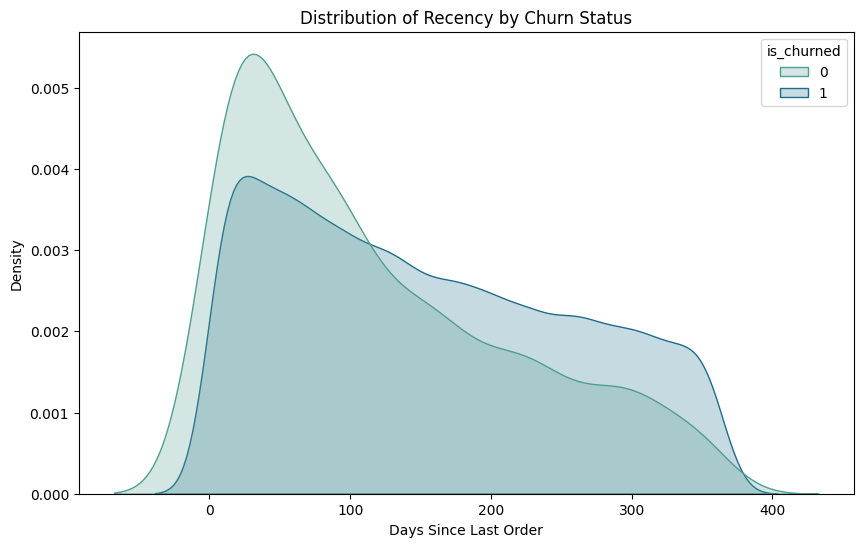

In [6]:
# Visualizing the separation between Churned (1) and Retained (0)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, x='days_since_last_order', hue='is_churned', 
    fill=True, 
    common_norm=False,  # scale each distribution independently. important since the classes are imbalanced!
    palette='crest'
    )
plt.title("Distribution of Recency by Churn Status")
plt.xlabel("Days Since Last Order")
plt.show()

### 🔎 Insight 2: Does "Bad Experience" Drive Churn?
**Hypothesis:** Users who return items (indicating a bad product fit) are more likely to churn.

**Analysis:**
We binned users by their return rate (Items Returned / Total Orders) to see if high return correlate with high churn.
* **Observation:** The churn rate is consistently high across all group (>95%). Interestingly, users with **moderate returns (1-10%)** actually show the highest risk, while "Super Returners" (50%+) are statistically safer.

> **💡 Business Recommendation:**
> "Serial Returners" are not our highest churn risk. We should **avoid penalizing high-return behaviors** (e.g., removing free returns), as these users are just as likely to stay as zero-return customers. The friction of a return does not appear to drive attrition.

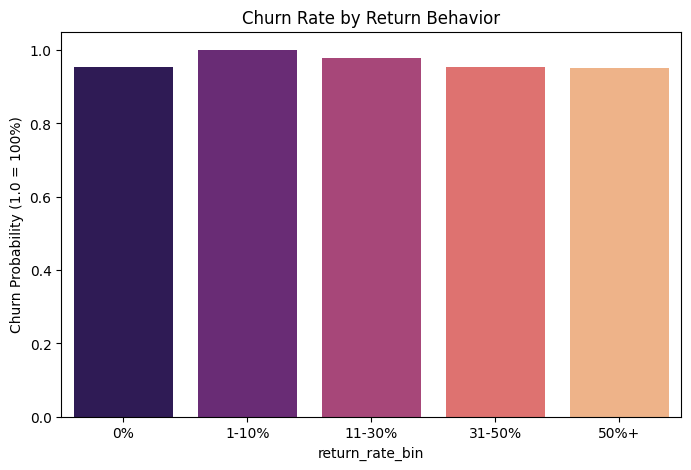

In [7]:
# Binning Return Rate to see trends
df['return_rate_bin'] = pd.cut(
    df['return_rate'], 
    bins=[-0.1, 0, 0.1, 0.3, 0.5, 1.0], 
    labels=["0%", "1-10%", "11-30%", "31-50%", "50%+"])

plt.figure(figsize=(8, 5))

# Look at the % of people who churned in each bin
sns.barplot(data=df, x='return_rate_bin', y='is_churned', errorbar=None, hue='return_rate_bin', palette='magma')
plt.title("Churn Rate by Return Behavior")
plt.ylabel("Churn Probability (1.0 = 100%)")
plt.show()

### 🔎 Insight 3: The "Whale" Trap: Does Spend Predict Loyalty?
**Hypothesis:** High-value customers ("Whales") are more loyal and less likely to churn than low-value buyers.

**Analysis:**
We compared the distribution of lifetime spend (`total_spend`) between Churned and Retained users to see if "VIPs" stick around longer.
* **Observation:** The distributions are nearly identical. The median spend for users who churned is indistinguishable from those who stayed. Being a "High Spender" provides **zero protection** against churning.

> **💡 Business Recommendation:**
> **Money doesn't buy loyalty.** We cannot rely on "VIP Status" (historical spend) to identify safe customers. A user who spent $500 last year is just as likely to leave as one who spent $50. Retention efforts should focus on **behavioral signals** (like Recency) rather than assuming high spenders are "safe."

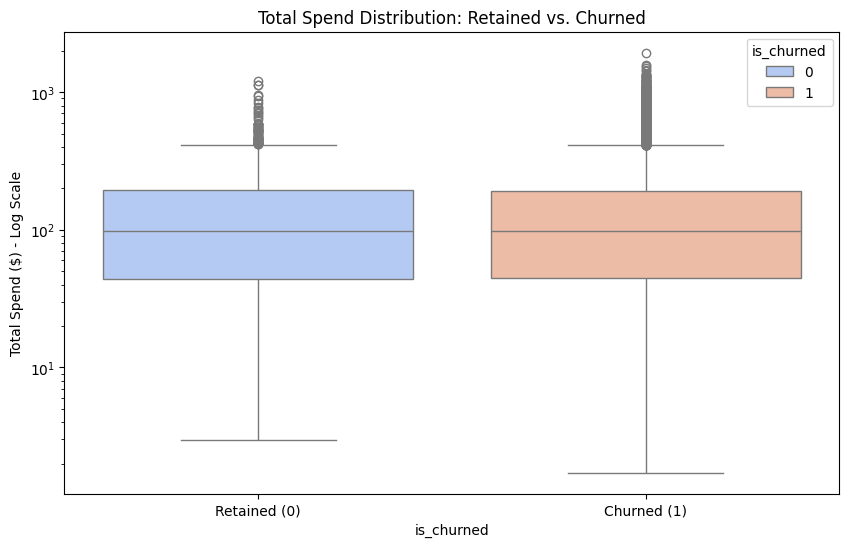

In [16]:
plt.figure(figsize=(10, 6))
# Log scale helps because spend is usually skewed
sns.boxplot(data=df, x='is_churned', y='total_spend', hue='is_churned', palette='coolwarm')
plt.yscale('log')
plt.title("Total Spend Distribution: Retained vs. Churned")
plt.ylabel("Total Spend ($) - Log Scale")
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.show()

## Modeling

In [9]:
# Preprocessing
# 1. Filp the target
# We want to predict who STAYS (1), because they are the "Needle in the Haystack"
# Current: 1 = Churned, 0 = Retained
# New: 1 = Retained, 0 = Churned
df['target_retained'] = df['is_churned'].apply(lambda x: 1 if x == 0 else 0)

# 2. Define features and target
y = df['target_retained']
X = df.drop(columns=['user_id', 'is_churned', 'target_retained', 'return_rate_bin'])

# 3. Split data (stratified to keep the 5% retention rate in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Calculate scale weight
# Logic: sum(majority) / sum(minority)
scale_pos_weight = (y_train == 0).sum() / (y_train ==1).sum()
print(f"Computed scale_pos_weight: {scale_pos_weight:.2f}")

Computed scale_pos_weight: 20.98


In [11]:
# Train XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

print("Training XGBoost Model...")
model.fit(X_train, y_train)
print("Done.")

Training XGBoost Model...
Done.


In [12]:
# Evaluation 
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Churned (0)', 'Retained (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.3f}")


--- Classification Report ---
              precision    recall  f1-score   support

 Churned (0)       0.96      0.62      0.76      6105
Retained (1)       0.06      0.49      0.10       291

    accuracy                           0.62      6396
   macro avg       0.51      0.56      0.43      6396
weighted avg       0.92      0.62      0.73      6396

ROC-AUC Score: 0.568


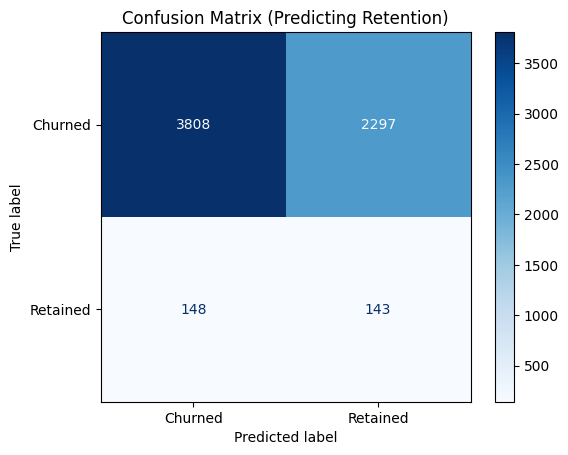

In [13]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Churned', 'Retained'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Predicting Retention)")
plt.show()

In [14]:
# Save the model (for the App later)
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Save test data for notebook 03 (evaluation)
X_test.to_csv(X_TEST_PATH, index=False)
y_test.to_csv(Y_TEST_PATH, index=False)
print(f"Test data saved to {X_TEST_PATH} and {Y_TEST_PATH}")

Model saved to ../models/churn_xgb_model.pkl
Test data saved to ../data/processed/X_test.csv and ../data/processed/y_test.csv


## Next

Proceed to `03_evaluation_and_insights.ipynb` to:

- choose an operating threshold (or top-k targeting)
- build plots for `README.md`
- produce a prioritized "at-risk" list with suggested actions